In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Install dependencies (uncomment if needed)
# !pip install xgboost openpyxl imbalanced-learn

# Import Libraries
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats.mstats import winsorize
import matplotlib.pyplot as plt

# Load data
file_path = "/content/drive/MyDrive/weather_train_cleaned.csv"
df = pd.read_csv(file_path)

# Convert datetime columns
df["CURR_ACTL_ARVL"] = pd.to_datetime(df["CURR_ACTL_ARVL"], format="%d-%m-%Y %H:%M", errors="coerce")
df["CURR_ACTL_DPRT"] = pd.to_datetime(df["CURR_ACTL_DPRT"], format="%d-%m-%Y %H:%M", errors="coerce")

# Handle delay columns
df["NEXT_DELAY_TIME"] = pd.to_numeric(df["NEXT_DELAY_TIME"], errors="coerce")
df["NEXT_DELAY_TIME"] = df["NEXT_DELAY_TIME"].apply(lambda x: max(x, 0) if pd.notnull(x) else x)
df['CURR_DPRT_DELAY'] = pd.to_numeric(df['CURR_DPRT_DELAY'], errors='coerce')

# Recency features
df["SAME_GROUP_SAME_DIR_RECENCY"] = df.groupby("TRAIN_GROUP")["NEXT_DELAY"].transform(lambda x: x.rolling(window=3, min_periods=1).mean())
df["ALL_GROUPS_SAME_DIR_RECENCY"] = df.groupby("CURR_STATION")["NEXT_DELAY"].transform(lambda x: x.rolling(window=3, min_periods=1).mean())

opposite_df = df[["TRAIN_GROUP", "CURR_STATION", "NEXT_STATION", "NEXT_DELAY"]].copy()
opposite_df.rename(columns={"CURR_STATION": "NEXT_STATION", "NEXT_STATION": "CURR_STATION"}, inplace=True)
opposite_recency = opposite_df.groupby(["TRAIN_GROUP", "CURR_STATION"])["NEXT_DELAY"].transform(lambda x: x.rolling(window=3, min_periods=1).mean())
df["SAME_GROUP_OPP_DIR_RECENCY"] = opposite_recency
opposite_recency_all = opposite_df.groupby("CURR_STATION")["NEXT_DELAY"].transform(lambda x: x.rolling(window=3, min_periods=1).mean())
df["ALL_GROUPS_OPP_DIR_RECENCY"] = opposite_recency_all

# Final RECENCY score
df["RECENCY"] = (
    df["SAME_GROUP_SAME_DIR_RECENCY"] * 0.5 +
    df["ALL_GROUPS_SAME_DIR_RECENCY"] * 0.2 +
    df["SAME_GROUP_OPP_DIR_RECENCY"] * 0.2 +
    df["ALL_GROUPS_OPP_DIR_RECENCY"] * 0.1
)
df.drop(columns=["ALL_GROUPS_OPP_DIR_RECENCY", "SAME_GROUP_OPP_DIR_RECENCY", "ALL_GROUPS_SAME_DIR_RECENCY", "SAME_GROUP_SAME_DIR_RECENCY"], inplace=True)

# Time features
df['MONTH'] = df['CURR_ACTL_DPRT'].dt.month
df['HOUR'] = df['CURR_ACTL_DPRT'].dt.hour
df['WEEKDAY'] = df['CURR_ACTL_DPRT'].dt.weekday
df["RUSH_HOUR"] = df["HOUR"].apply(lambda x: 5 if 7 <= x <= 10 or 17 <= x <= 20 else 0)

# Average delay per station
avg_delay_per_station = df.groupby("CURR_STATION")["NEXT_DELAY_TIME"].mean().reset_index()
avg_delay_per_station.columns = ["Station", "Average_Delay_Time_Minutes"]
df["AVG_DELAY_FOR_STATION"] = df["CURR_STATION"].map(avg_delay_per_station.set_index("Station")["Average_Delay_Time_Minutes"])

# Selected features
selected_columns = [
    'SECTION', 'DISTANCE', 'CURR_DISTANCE', 'NEXT_DISTACE', 'TRAIN_GROUP',
    'CURR_DELAY_TIME', 'ALWNC_EXT', 'NTES_EXT', 'CURR_STATION',
    'tempmax', 'visibility', 'conditions', 'DISTANCE_LEFT',
    'AVG_DELAY_FOR_STATION', 'RECENCY', 'NTES', 'MONTH', 'HOUR', 'WEEKDAY', 'RUSH_HOUR'
]
df_scaled = df[selected_columns + ['NEXT_DELAY_TIME']].copy()

# Encode weather condition
if 'conditions' in df_scaled.columns:
    le = LabelEncoder()
    df_scaled['conditions'] = le.fit_transform(df_scaled['conditions'].astype(str))

# Winsorize
for col in ['CURR_DELAY_TIME']:
    df_scaled[col] = winsorize(df_scaled[col], limits=[0.01, 0.01])

# Encode categorical features
label_encoders = {}
for col in ['CURR_STATION', 'SECTION', 'TRAIN_GROUP']:
    le = LabelEncoder()
    df_scaled[col] = le.fit_transform(df_scaled[col].astype(str))
    label_encoders[col] = le

# Drop nulls
df_scaled.dropna(inplace=True)

# Feature matrix and target
X = df_scaled.drop(columns=["NEXT_DELAY_TIME"])
y = df_scaled["NEXT_DELAY_TIME"]
from sklearn.preprocessing import StandardScaler
# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

#pip install xgboost scikit-learn
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, median_absolute_error
import numpy as np

param_dist = {
    'n_estimators': [100, 200, 300, 500 , 600 , 700],
    'max_depth': [3, 5, 6, 7, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2, 0.4],
    'min_child_weight': [1, 3, 5, 7]
}
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

random_search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    n_iter=50,   # Number of combinations to try (you can increase if you have time)
    scoring='neg_root_mean_squared_error',  # You can also use 'neg_mean_absolute_error'
    cv=3,        # 3-fold cross-validation
    verbose=2,
    random_state=42,
    n_jobs=-1    # Use all CPU cores
)

# Train Random Search
random_search.fit(X_train, y_train)
# Best parameters
print("Best Hyperparameters:", random_search.best_params_)

# Best model
best_xgb_model = random_search.best_estimator_

# Predict
train_pred_xgb = best_xgb_model.predict(X_train)
test_pred_xgb = best_xgb_model.predict(X_test)

# Evaluate
train_r2 = r2_score(y_train, train_pred_xgb)
test_r2 = r2_score(y_test, test_pred_xgb)

print(f"Train R2: {train_r2:.4f}")
print(f"Test R2: {test_r2:.4f}")


Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Hyperparameters: {'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0.2, 'colsample_bytree': 0.8}
Train R2: 0.8533
Test R2: 0.7947


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, median_absolute_error
import numpy as np

# RMSE
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred_xgb))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred_xgb))

# MAE
train_mae = mean_absolute_error(y_train, train_pred_xgb)
test_mae = mean_absolute_error(y_test, test_pred_xgb)

# MedAE (optional)
train_medae = median_absolute_error(y_train, train_pred_xgb)
test_medae = median_absolute_error(y_test, test_pred_xgb)

# Print
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Train MAE: {train_mae:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Train MedAE: {train_medae:.4f}")
print(f"Test MedAE: {test_medae:.4f}")


Train RMSE: 9.2539
Test RMSE: 10.9118
Train MAE: 4.7992
Test MAE: 5.5705
Train MedAE: 1.6365
Test MedAE: 1.8059


In [ ]:
# Calculate absolute error between prediction and actual
test_abs_error = np.abs(y_test.values - test_pred_xgb)

# Create a results DataFrame
results_df_test = pd.DataFrame({
    "Actual NEXT_DELAY_TIME": y_test.values,
    "XGB Prediction": test_pred_xgb,
    "Absolute Error (min)": test_abs_error
})

# Categorize based on absolute error
results_df_test["Category"] = pd.cut(results_df_test["Absolute Error (min)"],
                                     bins=[-0.1, 5, 10, 15, float("inf")],
                                     labels=["<5 min", "<10 min", "<15 min", ">15 min (Abnormal)"])

# Calculate percentage breakdown
error_counts = results_df_test["Category"].value_counts(normalize=True).sort_index() * 100

# Display nicely
print("Absolute Error Breakdown (%):")
print(error_counts)


Absolute Error Breakdown (%):
Category
<5 min                69.056232
<10 min               14.056381
<15 min                6.505037
>15 min (Abnormal)    10.382350
Name: proportion, dtype: float64


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Normalize (already done earlier)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Define and compile DNN model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1)
])
model.compile(optimizer=Adam(learning_rate=0.001), loss=tf.keras.losses.Huber(delta=7.0), metrics=[tf.keras.metrics.RootMeanSquaredError()])

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=80, batch_size=32, verbose=1)

# Predict
train_pred_dnn = model.predict(X_train).flatten()
test_pred_dnn = model.predict(X_test).flatten()

# Metrics
train_r2_dnn = r2_score(y_train, train_pred_dnn)
test_r2_dnn = r2_score(y_test, test_pred_dnn)
train_rmse_dnn = np.sqrt(mean_squared_error(y_train, train_pred_dnn))
test_rmse_dnn = np.sqrt(mean_squared_error(y_test, test_pred_dnn))
train_mae_dnn = mean_absolute_error(y_train, train_pred_dnn)
test_mae_dnn = mean_absolute_error(y_test, test_pred_dnn)
train_medae_dnn = median_absolute_error(y_train, train_pred_dnn)
test_medae_dnn = median_absolute_error(y_test, test_pred_dnn)

print(f"DNN Train R2: {train_r2_dnn:.4f}")
print(f"DNN Test R2: {test_r2_dnn:.4f}")
print(f"DNN Train RMSE: {train_rmse_dnn:.4f}")
print(f"DNN Test RMSE: {test_rmse_dnn:.4f}")
print(f"DNN Train MAE: {train_mae_dnn:.4f}")
print(f"DNN Test MAE: {test_mae_dnn:.4f}")
print(f"DNN Train MedAE: {train_medae_dnn:.4f}")
print(f"DNN Test MedAE: {test_medae_dnn:.4f}")

# Error categories on test set
test_abs_error_dnn = np.abs(y_test.values - test_pred_dnn)

results_df_test_dnn = pd.DataFrame({
    "Actual NEXT_DELAY_TIME": y_test.values,
    "DNN Prediction": test_pred_dnn,
    "Absolute Error (min)": test_abs_error_dnn
})

results_df_test_dnn["Category"] = pd.cut(
    results_df_test_dnn["Absolute Error (min)"],
    bins=[-0.1, 5, 10, 15, float("inf")],
    labels=["<5 min", "<10 min", "<15 min", ">15 min (Abnormal)"]
)

# Percentage breakdown
error_counts_dnn = results_df_test_dnn["Category"].value_counts(normalize=True).sort_index() * 100
print(error_counts_dnn)

# Train set predictions dataframe
results_df_train_dnn = pd.DataFrame({
    "Actual NEXT_DELAY_TIME": y_train.values,
    "DNN Prediction": train_pred_dnn,
    "Absolute Error (min)": np.abs(y_train.values - train_pred_dnn)
})


Epoch 1/80


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2440/2440 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 39.5556 - root_mean_squared_error: 16.2837 - val_loss: 28.7730 - val_root_mean_squared_error: 11.9615
Epoch 2/80
2440/2440 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 30.3835 - root_mean_squared_error: 12.5355 - val_loss: 27.7540 - val_root_mean_squared_error: 11.9561
Epoch 3/80
2440/2440 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 29.7611 - root_mean_squared_error: 12.4452 - val_loss: 27.8062 - val_root_mean_squared_error: 11.9413
Epoch 4/80
2440/2440 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 29.3712 - root_mean_squared_error: 12.3371 - val_loss: 27.2206 - val_root_mean_squared_error: 11.7876
Epoch 5/80
2440/2440 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 29.6886 - root_mean_squared_error: 12.6129 - val_loss: 27.6558 - val_root_mean_squared_error: 11.8606
Epoch 6/80
2440/2440 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 29.6000 - root_mean_squared_error: 12.5809 - val_loss: 27.4025 - val_root_mean_squared_error: 12.0192
Epoch 7/80
2440/2440 ━━━━

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, median_absolute_error
import numpy as np

# Step 1: Calculate individual RMSE (assuming you already have model predictions)
test_rmse_xgb = np.sqrt(mean_squared_error(y_test, test_pred_xgb))
test_rmse_dnn = np.sqrt(mean_squared_error(y_test, test_pred_dnn))

# Step 2: Dynamic weights based on inverse RMSE
weight_xgb = 1 / test_rmse_xgb
weight_dnn = 1 / test_rmse_dnn
sum_weights = weight_xgb + weight_dnn
weight_xgb /= sum_weights
weight_dnn /= sum_weights

print(f"Dynamic Weights → XGB: {weight_xgb:.4f}, DNN: {weight_dnn:.4f}")

# Step 3: Ensemble prediction
test_pred_ensemble = weight_xgb * test_pred_xgb + weight_dnn * test_pred_dnn

# Step 4: Evaluation Metrics
test_r2_ensemble = r2_score(y_test, test_pred_ensemble)
test_rmse_ensemble = np.sqrt(mean_squared_error(y_test, test_pred_ensemble))
test_mae_ensemble = mean_absolute_error(y_test, test_pred_ensemble)
test_medae_ensemble = median_absolute_error(y_test, test_pred_ensemble)

print(f"Ensemble Test R2: {test_r2_ensemble:.4f}")
print(f"Ensemble Test RMSE: {test_rmse_ensemble:.4f}")
print(f"Ensemble Test MAE: {test_mae_ensemble:.4f}")
print(f"Ensemble Test MedAE: {test_medae_ensemble:.4f}")

# Step 5: Absolute Error Buckets
absolute_errors = np.abs(y_test - test_pred_ensemble)

less_than_5 = np.sum(absolute_errors < 5)
less_than_10 = np.sum((absolute_errors >= 5) & (absolute_errors < 10))
less_than_15 = np.sum((absolute_errors >= 10) & (absolute_errors < 15))
greater_than_15 = np.sum(absolute_errors >= 15)

total = len(absolute_errors)

print("\nError Bucket Distribution:")
print(f"< 5 min : {less_than_5} cases ({(less_than_5/total)*100:.2f}%)")
print(f"5-10 min : {less_than_10} cases ({(less_than_10/total)*100:.2f}%)")
print(f"10-15 min : {less_than_15} cases ({(less_than_15/total)*100:.2f}%)")
print(f"> 15 min : {greater_than_15} cases ({(greater_than_15/total)*100:.2f}%)")


Dynamic Weights → XGB: 0.5139, DNN: 0.4861
Ensemble Test R2: 0.7913
Ensemble Test RMSE: 11.0020
Ensemble Test MAE: 5.4073
Ensemble Test MedAE: 1.5655

Error Bucket Distribution:
< 5 min : 23593 cases (70.53%)
5-10 min : 4524 cases (13.52%)
10-15 min : 2068 cases (6.18%)
> 15 min : 3266 cases (9.76%)


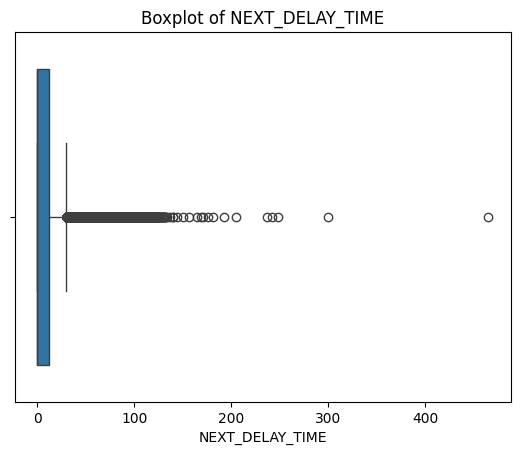

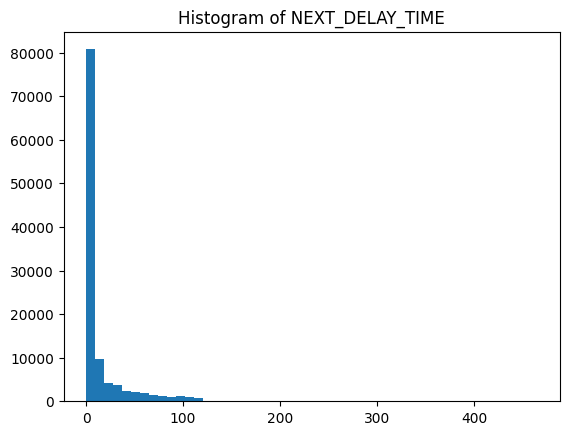

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing the distribution of the target variable
sns.boxplot(x=df['NEXT_DELAY_TIME'])
plt.title('Boxplot of NEXT_DELAY_TIME')
plt.show()

# Visualizing the distribution of the target variable using a histogram
plt.hist(df['NEXT_DELAY_TIME'], bins=50)
plt.title('Histogram of NEXT_DELAY_TIME')
plt.show()

In [ ]:
# Increase weight for the model that's performing better on smaller delays
weight_xgb = 1 / (test_rmse_xgb + 0.5)  # Slight adjustment to prioritize low-error predictions
weight_dnn = 1 / (test_rmse_dnn + 0.5)  # Same for DNN
sum_weights = weight_xgb + weight_dnn
weight_xgb /= sum_weights
weight_dnn /= sum_weights

# Print weights after modification
print(f"Adjusted Weights → XGB: {weight_xgb:.4f}, DNN: {weight_dnn:.4f}")

# Ensemble prediction
test_pred_ensemble = weight_xgb * test_pred_xgb + weight_dnn * test_pred_dnn

# Recalculate metrics
test_r2_ensemble = r2_score(y_test, test_pred_ensemble)
test_rmse_ensemble = np.sqrt(mean_squared_error(y_test, test_pred_ensemble))
test_mae_ensemble = mean_absolute_error(y_test, test_pred_ensemble)
test_medae_ensemble = median_absolute_error(y_test, test_pred_ensemble)

# Print new evaluation
print(f"Ensemble Test R2: {test_r2_ensemble:.4f}")
print(f"Ensemble Test RMSE: {test_rmse_ensemble:.4f}")
print(f"Ensemble Test MAE: {test_mae_ensemble:.4f}")
print(f"Ensemble Test MedAE: {test_medae_ensemble:.4f}")


Adjusted Weights → XGB: 0.5133, DNN: 0.4867
Ensemble Test R2: 0.7913
Ensemble Test RMSE: 11.0024
Ensemble Test MAE: 5.4072
Ensemble Test MedAE: 1.5647


In [ ]:
import pandas as pd
import numpy as np

# ======== Train set: DNN and XGB predictions =========
train_pred_xgb = best_xgb_model.predict(X_train)
train_pred_dnn = model.predict(X_train).flatten()
train_pred_ensemble = weight_xgb * train_pred_xgb + weight_dnn * train_pred_dnn

# ======== Error calculations on Train =========
train_absolute_errors = np.abs(y_train - train_pred_ensemble)

# Train error bucket distribution
train_less_than_5 = np.sum(train_absolute_errors < 5) / len(train_absolute_errors) * 100
train_less_than_10 = np.sum((train_absolute_errors >= 5) & (train_absolute_errors < 10)) / len(train_absolute_errors) * 100
train_less_than_15 = np.sum((train_absolute_errors >= 10) & (train_absolute_errors < 15)) / len(train_absolute_errors) * 100
train_greater_than_15 = np.sum(train_absolute_errors >= 15) / len(train_absolute_errors) * 100

# Train metrics
train_rmse_ensemble = np.sqrt(mean_squared_error(y_train, train_pred_ensemble))
train_mae_ensemble = mean_absolute_error(y_train, train_pred_ensemble)
train_medae_ensemble = median_absolute_error(y_train, train_pred_ensemble)
train_r2_ensemble = r2_score(y_train, train_pred_ensemble)

# ======== Test set already computed earlier =========
# Using test_pred_ensemble you have from your code
test_absolute_errors = np.abs(y_test - test_pred_ensemble)

# Test error bucket distribution
test_less_than_5 = np.sum(test_absolute_errors < 5) / len(test_absolute_errors) * 100
test_less_than_10 = np.sum((test_absolute_errors >= 5) & (test_absolute_errors < 10)) / len(test_absolute_errors) * 100
test_less_than_15 = np.sum((test_absolute_errors >= 10) & (test_absolute_errors < 15)) / len(test_absolute_errors) * 100
test_greater_than_15 = np.sum(test_absolute_errors >= 15) / len(test_absolute_errors) * 100

# Test metrics
# Already available from your code:
# test_rmse_ensemble, test_mae_ensemble, test_medae_ensemble, test_r2_ensemble

# ======== Create DataFrames =========

train_metrics = pd.DataFrame({
    "Dataset": ["Train"],
    "RMSE": [train_rmse_ensemble],
    "MAE": [train_mae_ensemble],
    "MedAE": [train_medae_ensemble],
    "R2_Score": [train_r2_ensemble],
    "<5 mins (%)": [train_less_than_5],
    "5-10 mins (%)": [train_less_than_10],
    "10-15 mins (%)": [train_less_than_15],
    ">15 mins (%)": [train_greater_than_15]
})

test_metrics = pd.DataFrame({
    "Dataset": ["Test"],
    "RMSE": [test_rmse_ensemble],
    "MAE": [test_mae_ensemble],
    "MedAE": [test_medae_ensemble],
    "R2_Score": [test_r2_ensemble],
    "<5 mins (%)": [test_less_than_5],
    "5-10 mins (%)": [test_less_than_10],
    "10-15 mins (%)": [test_less_than_15],
    ">15 mins (%)": [test_greater_than_15]
})

# ======== Combine and Save =========
final_metrics = pd.concat([train_metrics, test_metrics], ignore_index=True)

# Save to Excel
final_metrics.to_excel("/content/drive/MyDrive/final_ensemble_metrics.xlsx", index=False)

print(final_metrics)


2440/2440 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
  Dataset       RMSE       MAE    MedAE  R2_Score  <5 mins (%)  5-10 mins (%)  \
0   Train  10.108293  4.952209  1.47478  0.825004    72.190335      13.685748   
1    Test  11.002405  5.407232  1.56473  0.791320    70.538997      13.521270   

   10-15 mins (%)  >15 mins (%)  
0        5.516835      8.607082  
1        6.176198      9.763535  


In [ ]:
# ======== Inverse transform (descale) the features =========

# Descale X_train and X_test
X_train_original = scaler.inverse_transform(X_train)
X_test_original = scaler.inverse_transform(X_test)

# Convert to DataFrames with proper feature names
X_train_df = pd.DataFrame(X_train_original, columns=selected_columns)
X_test_df = pd.DataFrame(X_test_original, columns=selected_columns)

# ======== Add true and predicted next_delay_time =========

train_samples_with_predictions = X_train_df.copy()
train_samples_with_predictions["True_Next_Delay"] = y_train
train_samples_with_predictions["Predicted_Next_Delay"] = train_pred_ensemble

test_samples_with_predictions = X_test_df.copy()
test_samples_with_predictions["True_Next_Delay"] = y_test
test_samples_with_predictions["Predicted_Next_Delay"] = test_pred_ensemble

# ======== Save to Excel =========

train_samples_with_predictions.to_excel("/content/drive/MyDrive/final_train_samples_with_predictions.xlsx", index=False)
test_samples_with_predictions.to_excel("/content/drive/MyDrive/final_test_samples_with_predictions.xlsx", index=False)

print("Train and Test samples (with descaled features) saved successfully!")


Train and Test samples (with descaled features) saved successfully!


In [ ]:
# Descale X_train and X_test
X_train_original = scaler.inverse_transform(X_train)
X_test_original = scaler.inverse_transform(X_test)

# Create DataFrames
X_train_df = pd.DataFrame(X_train_original, columns=selected_columns)
X_test_df = pd.DataFrame(X_test_original, columns=selected_columns)

# Drop "ntes" and "ntes_ext" columns if they exist
columns_to_drop = ["NTES", "NTES_EXT"]
X_train_df = X_train_df.drop(columns=columns_to_drop, errors='ignore')
X_test_df = X_test_df.drop(columns=columns_to_drop, errors='ignore')

# Align and add true + predicted next delay
train_samples_with_predictions = X_train_df.copy()
train_samples_with_predictions["True_Next_Delay"] = y_train.reset_index(drop=True)
train_samples_with_predictions["Predicted_Next_Delay"] = train_pred_ensemble

test_samples_with_predictions = X_test_df.copy()
test_samples_with_predictions["True_Next_Delay"] = y_test.reset_index(drop=True)
test_samples_with_predictions["Predicted_Next_Delay"] = test_pred_ensemble

# Save to Excel: two sheets in one file
with pd.ExcelWriter("/content/drive/MyDrive/train_test_samples_with_predictions.xlsx") as writer:
    train_samples_with_predictions.to_excel(writer, sheet_name="Train", index=False)
    test_samples_with_predictions.to_excel(writer, sheet_name="Test", index=False)

print("✅ Saved train and test samples with predictions to Excel.")


✅ Saved train and test samples with predictions to Excel.
